# 9.4 Publication Text Analysis - step 4: Topic Modeling

This notebook:

1. Fits a topic model (NMF, with LDA as a comparison) on the publication-level text corpus
2. Picks a number of topics k
3. Checks whether topics are broad, cross-lab patterns or artifacts of one or two prolific labs (the same issue we found with individual terms in 9_3). Removes single lab artifact topics.
4. Aggregates to lab-level topic shares for the regression in 9_5
5. Preliminary logistic regression with Lasso to see how well topics predict energy use

In [1]:
# Set up
import pandas as pd
import numpy as np
import sys
from pathlib import Path
CODE_ROOT = Path.cwd().parents[1]
sys.path.append(str(CODE_ROOT))
import config
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [2]:
# Load data
publications = pd.read_csv(
    config.PUBLICATON_DATA / "3_Clean" / "publications_unique.csv"
)

pub_lab_map = pd.read_csv(
    config.PUBLICATON_DATA / "3_Clean" / "pub_lab_mapping.csv"
)

lab_data = pd.read_csv(
    config.PUBLICATON_DATA / "3_Clean" / "lab_level_subject_shares.csv"
)

print(f"Publications: {publications.shape[0]:,}")
print(f"Pub-lab mapping rows: {pub_lab_map.shape[0]:,}")
print(f"Labs: {lab_data.shape[0]}")

Publications: 8,014
Pub-lab mapping rows: 8,435
Labs: 95


## (1) Create TF-IDF matrix

We use same parameters as in 9_3 (min_df = 3, max_df = 0.95, unigrams and bigrams, English stopwords).

In [3]:
# Create TF-IDF matrix
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_df=0.95,
    min_df=3,
)
X = tfidf.fit_transform(publications["text_final"])
vocab = tfidf.get_feature_names_out()

print(f"Matrix shape: {X.shape[0]:,} documents x {X.shape[1]:,} vocabulary terms")

Matrix shape: 8,014 documents x 44,351 vocabulary terms


## (2) Topic modelling

### (2.1) First attempt - choose k = 15

In [4]:
# Choose k = 15 topics for the first attempt
N_TOPICS_FIRST_PASS = 15

# Fit NMF model
nmf = NMF(n_components=N_TOPICS_FIRST_PASS, random_state=0, max_iter=500)
doc_topics = nmf.fit_transform(X)  # documents x topics
topic_terms = nmf.components_       # topics x terms

print(f"doc_topics shape: {doc_topics.shape}")
print(f"topic_terms shape: {topic_terms.shape}")

doc_topics shape: (8014, 15)
topic_terms shape: (15, 44351)


In [5]:
# Display top 10 words for each topic
N_TOP_WORDS = 10

for topic_idx, topic in enumerate(topic_terms):
    top_word_idx = topic.argsort()[::-1][:N_TOP_WORDS]
    top_words = [vocab[i] for i in top_word_idx]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")

Topic 0: proton, 13 tev, sqrt 13, 13, proton proton, proton collisions, tev, sqrt, collisions sqrt, collisions
Topic 1: value documentation, documentation, mak value, value, mak, documentation german, german language, language, 2018, language 2018
Topic 2: species, diversity, plant, soil, richness, species richness, biodiversity, forest, tree, climate
Topic 3: pi, pm, decays, cp, pi pi, decay, psi, violation, cp violation, rightarrow
Topic 4: mak, value, m3, mak value, mg, toxicity, ml m3, ml, commission, rats
Topic 5: prodromus, prodromus fern, flora bolivia, fern flora, bolivia, flora, fern, new, dryopteridaceae, sm
Topic 6: ebv, cells, cell, immune, virus, human, infection, nk, mice, barr
Topic 7: qcd, boson, production, corrections, higgs, order, nnlo, jet, higgs boson, leading
Topic 8: german version, translation german, translation, version, supplement, supplement translation, mak, documentation supplement, value documentation, documentation
Topic 9: neuromorphic, neural, circuit

We see that the topic categories seem to make sense - we see similar patterns to what we saw for the top words in 9_3 - biology/wet labs (topic 6), mak docs (topic 4). We also see several topics regarding particle physics type research (topics 0, 3, 6, 10, 13).

### (2.2) choose k

We choose k based on the following:

(a) Redundancy - near-duplicate topics
(b) Single-lab artifacts
(c) Catch-all topics

In [6]:
# Function to evaluate NMF model for given number of topics k
def evaluate_k(k):
    nmf_k = NMF(n_components=k, random_state=0, max_iter=500)
    doc_topics_k = nmf_k.fit_transform(X)
    topic_terms_k = nmf_k.components_

    # Redundancy: check highest pairwise cosine similarity between any two topics
    sim = cosine_similarity(topic_terms_k)
    np.fill_diagonal(sim, 0)
    max_similarity = sim.max()

    # Artifact topics: check number of topics where >90% of publications come from a single lab
    dominant = doc_topics_k.argmax(axis=1)
    pub_topic = pd.DataFrame({"pub_id": publications["pub_id"].values, "dominant_topic": dominant})
    pub_topic_lab_k = pub_lab_map.merge(pub_topic, on="pub_id", how="left")

    def top_lab_share_fn(group):
        counts = group["labgroupid"].value_counts()
        return counts.iloc[0] / counts.sum()

    top_share = pub_topic_lab_k.groupby("dominant_topic").apply(top_lab_share_fn, include_groups=False)

    n_artifact_topics = int((top_share > 0.9).sum())

    return {
        "k": k,
        "max_pairwise_similarity": round(max_similarity, 3),
        "n_artifact_topics": n_artifact_topics,
        "reconstruction_err": round(nmf_k.reconstruction_err_, 1), # reconstruction error
    }

K_VALUES = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
scan_results = [evaluate_k(k) for k in K_VALUES]
scan_df = pd.DataFrame(scan_results)
print(scan_df.to_string(index=False))

 k  max_pairwise_similarity  n_artifact_topics  reconstruction_err
 4                    0.143                  1                87.6
 5                    0.288                  2                87.4
 6                    0.288                  3                87.2
 7                    0.288                  3                87.0
 8                    0.288                  3                86.9
 9                    0.406                  4                86.7
10                    0.406                  4                86.6
11                    0.406                  4                86.4
12                    0.407                  4                86.3
13                    0.407                  4                86.2
14                    0.407                  4                86.1
15                    0.415                  4                85.9
16                    0.414                  4                85.8
17                    0.414                  4                

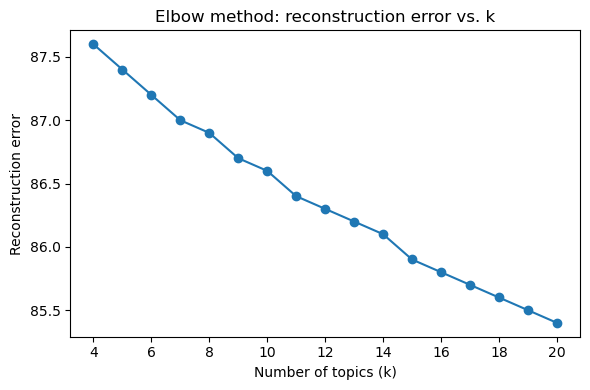

In [7]:
# Elbow method: plot reconstruction error vs k
all_scan = pd.concat([scan_df], ignore_index=True).sort_values("k")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(all_scan["k"], all_scan["reconstruction_err"], marker="o")
ax.set_xlabel("Number of topics (k)")
ax.set_ylabel("Reconstruction error")
ax.set_title("Elbow method: reconstruction error vs. k")
plt.tight_layout()
plt.show()

Redundancy tends to rise with k. Artifact topics rise gradually. Reconstruction error gradually decreases. We next inspect the most common terms to check for catch-all topics.

In [8]:
# Visually inspect topics for different values of k
def print_topics_at_k(k, n_words=10):
    nmf_k = NMF(n_components=k, random_state=0, max_iter=500)
    nmf_k.fit(X)
    print(f"Number of topics k={k} :")
    for topic_idx, topic in enumerate(nmf_k.components_):
        top_word_idx = topic.argsort()[::-1][:n_words]
        top_words = [vocab[i] for i in top_word_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")
    print()

for k in [4, 5, 6, 7, 8, 10, 12]:
    print_topics_at_k(k)

Number of topics k=4 :
Topic 0: proton, tev, sqrt, collisions, 13 tev, collisions sqrt, sqrt 13, 13, proton proton, proton collisions
Topic 1: mak, value, mak value, value documentation, documentation, german, documentation german, german language, 2018, language
Topic 2: species, cells, cell, data, based, high, study, cancer, human, ebv
Topic 3: pi, mu, pm, decays, decay, cp, pi pi, psi, mu mu, rightarrow

Number of topics k=5 :
Topic 0: proton, tev, sqrt, collisions, 13 tev, collisions sqrt, sqrt 13, 13, proton proton, proton collisions
Topic 1: value documentation, documentation, mak value, mak, value, german, 2018, documentation german, german language, language
Topic 2: species, cells, cell, data, based, ebv, high, human, cancer, using
Topic 3: pi, mu, pm, decays, decay, cp, pi pi, psi, mu mu, rightarrow
Topic 4: mak, value, m3, mak value, mg, toxicity, ml, ml m3, commission, concentration

Number of topics k=6 :
Topic 0: proton, tev, sqrt, collisions, 13 tev, collisions sqrt, sqr

k = 4 merges ecology, immunology/virology, and cancer research into a single topic. k = 7 is the smallest k where that topic is distinct, and improves on the redundancy observed with higher k.

### (2.3) Final choice: k = 7

In [9]:
N_TOPICS_FINAL = 7

nmf = NMF(n_components=N_TOPICS_FINAL, random_state=0, max_iter=500)
doc_topics = nmf.fit_transform(X)
topic_terms = nmf.components_

print(f"doc_topics shape: {doc_topics.shape}")
print(f"topic_terms shape: {topic_terms.shape}")

for topic_idx, topic in enumerate(topic_terms):
    top_word_idx = topic.argsort()[::-1][:10]
    top_words = [vocab[i] for i in top_word_idx]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")

doc_topics shape: (8014, 7)
topic_terms shape: (7, 44351)
Topic 0: proton, tev, sqrt, 13 tev, collisions, collisions sqrt, sqrt 13, 13, proton proton, proton collisions
Topic 1: value documentation, documentation, mak value, mak, value, german, 2018, documentation german, german language, language
Topic 2: species, based, data, high, using, results, diversity, plant, different, neuromorphic
Topic 3: pi, mu, pm, decays, decay, cp, pi pi, psi, mu mu, rightarrow
Topic 4: mak, value, m3, mak value, mg, toxicity, ml, ml m3, commission, concentration
Topic 5: prodromus, flora bolivia, prodromus fern, fern flora, bolivia, flora, fern, species, new, dryopteridaceae
Topic 6: ebv, cells, cell, immune, virus, human, infection, nk, barr, epstein barr


## (3) Check whether each topic is broad pattern or reflecting 1/2 labs

In [10]:
# Each publication's single dominant topic (highest weight)
publications["dominant_topic"] = doc_topics.argmax(axis=1)

# Join to labs via the pub-lab mapping
pub_topic_lab = pub_lab_map.merge(
    publications[["pub_id", "dominant_topic"]], on="pub_id", how="left"
)

# Summarize topics by number of pubs, number of distinct labs, and share of pubs from the top lab
def top_lab_share(group):
    counts = group["labgroupid"].value_counts()
    return counts.iloc[0] / counts.sum()

topic_summary = pd.DataFrame({
    "n_pubs": pub_topic_lab.groupby("dominant_topic").size(),
    "n_distinct_labs": pub_topic_lab.groupby("dominant_topic")["labgroupid"].nunique(),
    "top_lab_share": pub_topic_lab.groupby("dominant_topic").apply(top_lab_share, include_groups=False),
})

def get_top_words(topic_idx, n=8):
    top_word_idx = topic_terms[topic_idx].argsort()[::-1][:n]
    return ", ".join(vocab[i] for i in top_word_idx)

topic_summary["top_words"] = [get_top_words(i) for i in topic_summary.index]

pd.set_option("display.max_colwidth", 100)
print(topic_summary.sort_values("n_distinct_labs").to_string())

                n_pubs  n_distinct_labs  top_lab_share                                                                                      top_words
dominant_topic                                                                                                                                       
5                   93                2       0.946237            prodromus, flora bolivia, prodromus fern, fern flora, bolivia, flora, fern, species
1                  332                7       0.969880  value documentation, documentation, mak value, mak, value, german, 2018, documentation german
3                  903               15       0.499446                                                      pi, mu, pm, decays, decay, cp, pi pi, psi
0                  799               16       0.724656                            proton, tev, sqrt, 13 tev, collisions, collisions sqrt, sqrt 13, 13
4                  548               19       0.941606                                             m

## (4) Aggregate to lab-level topic shares

In [11]:
# Normalize each publication's topic weights to a proper distribution (sums to 1)
zero_weight_docs = (doc_topics.sum(axis=1) == 0).sum()
print(f"Publications with no usable vocab (excluded from topic shares): {zero_weight_docs}")

with np.errstate(invalid="ignore"):
    doc_topic_shares = doc_topics / doc_topics.sum(axis=1, keepdims=True)

topic_cols = [f"topic_{i}" for i in range(doc_topic_shares.shape[1])]
doc_topic_df = pd.DataFrame(doc_topic_shares, columns=topic_cols)
doc_topic_df["pub_id"] = publications["pub_id"].values

# Join to labs, then average within each lab across that lab's own publications
pub_lab_topics = pub_lab_map.merge(doc_topic_df, on="pub_id", how="left")
lab_topic_shares = pub_lab_topics.groupby("labgroupid")[topic_cols].mean().reset_index()

print(f"lab_topic_shares shape: {lab_topic_shares.shape}")
print(f"Each lab's topic shares still sum to ~1: {lab_topic_shares[topic_cols].sum(axis=1).describe()[['min','max']].to_dict()}")
# lab_topic_shares.head(3)

Publications with no usable vocab (excluded from topic shares): 36
lab_topic_shares shape: (95, 8)
Each lab's topic shares still sum to ~1: {'min': 0.9999999999999998, 'max': 1.0000000000000002}


## (4.5) Exclude single-lab artifact topics

Drop topics where top_lab_share > 0.9.

In [12]:
flagged_topics = topic_summary[topic_summary["top_lab_share"] > 0.9].index.tolist()
flagged_cols = [f"topic_{i}" for i in flagged_topics]

print("Excluding single-lab artifact topics:")
print(topic_summary.loc[flagged_topics, ["n_pubs", "n_distinct_labs", "top_lab_share", "top_words"]].to_string())

topic_cols = [c for c in topic_cols if c not in flagged_cols]
lab_topic_shares_final = lab_topic_shares.drop(columns=flagged_cols)

print(f"\nRemaining topics: {len(topic_cols)} / {len(topic_cols) + len(flagged_cols)}")

Excluding single-lab artifact topics:
                n_pubs  n_distinct_labs  top_lab_share                                                                                      top_words
dominant_topic                                                                                                                                       
1                  332                7       0.969880  value documentation, documentation, mak value, mak, value, german, 2018, documentation german
4                  548               19       0.941606                                             mak, value, m3, mak value, mg, toxicity, ml, ml m3
5                   93                2       0.946237            prodromus, flora bolivia, prodromus fern, fern flora, bolivia, flora, fern, species

Remaining topics: 4 / 7


3 topics excluded. Topic 1 and 4 are German MAK safety-documentation. Topic 5 is botany.

## (5) Save lab-level topic shares

In [13]:
lab_topic_shares_final.to_csv(
    config.PUBLICATON_DATA / "3_Clean" / "lab_topic_shares.csv",
    index=False,
)

In [14]:
# Create df of topic top words for remaining topics
topic_words = topic_summary[["top_words"]].copy()
topic_words["topic"] = topic_words.index
topic_words_df = topic_words[topic_words["topic"].isin([int(c.split("_")[1]) for c in topic_cols])].copy()

# Print top words
print("Topic top words")
print(topic_words_df.to_string(index=False))

Topic top words
                                                          top_words  topic
proton, tev, sqrt, 13 tev, collisions, collisions sqrt, sqrt 13, 13      0
       species, based, data, high, using, results, diversity, plant      2
                          pi, mu, pm, decays, decay, cp, pi pi, psi      3
              ebv, cells, cell, immune, virus, human, infection, nk      6


We assign names to the topics:
topic 0: collider physics
topic 2: general / broad
topic 3: flavour physics
topic 6: immunology and virology

In [15]:
# Assign topic names based on top words
topic_dict = {
    0: "Collider physics",
    2: "General/broad",
    3: "Flavour physics",
    6: "Immunology and virology"
}
topic_words_df["topic_label"] = topic_words_df["topic"].map(topic_dict)

# Save topic names and top words
topic_words_path = config.PUBLICATON_DATA / "3_Clean" / "topic_top_words.csv"
topic_words_df.to_csv(topic_words_path, index=False)

## (6) Quick check: do topic shares predict high/low energy use?

We do the real analysis in 9_5 but this is just a quick check to see whether the topic shares are predictive.

In [16]:
# Create high/low energy tier variable
median_energy = lab_data["annual_electricity_total"].median()
lab_data["energy_tier"] = np.where(lab_data["annual_electricity_total"] >= median_energy, 1, 0)

# Merge the topic shares data with the energy tier data
model_data = lab_topic_shares_final.merge(lab_data[["labgroupid", "energy_tier"]], on="labgroupid", how="inner")
print(f"Labs with both topic shares and an energy tier: {len(model_data)}")

# Prepare the data for modelling
X_topics = model_data[topic_cols].values
y = model_data["energy_tier"].values

Labs with both topic shares and an energy tier: 95


In [17]:
# Nested cross-validation to evaluate Lasso logistic regression with hyperparameter tuning (C)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# We use LogisticRegressionCV to perform inner cross-validation for hyperparameter tuning (C)
# - penalty="l1" = Lasso
# - Cs=10 searches 10 values on a log scale
# - cv=5 is the inner cross-validation used to pick C
# StandardScaler is included in a Pipeline so it's fit only on each outer fold's training
# data (no leakage from the held-out fold), matching the fix used in 9_5's LassoCV.
lasso_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LogisticRegressionCV(
        Cs=10,
        cv=5,
        penalty="l1",
        solver="liblinear",
        max_iter=5000,
        random_state=0,
    )),
])

# Perform nested cross-validation to evaluate the model's performance
cv_accuracy_lasso = cross_val_score(lasso_clf, X_topics, y, cv=outer_cv, scoring="accuracy")
cv_auc_lasso = cross_val_score(lasso_clf, X_topics, y, cv=outer_cv, scoring="roc_auc")

# Report results
print(f"Nested CV accuracy (Lasso, tuned C): {cv_accuracy_lasso.mean():.1%} (+/- {cv_accuracy_lasso.std():.1%} across folds)")
print(f"Nested CV ROC-AUC (Lasso, tuned C):  {cv_auc_lasso.mean():.3f} (+/- {cv_auc_lasso.std():.3f} across folds)")

Nested CV accuracy (Lasso, tuned C): 78.9% (+/- 6.7% across folds)
Nested CV ROC-AUC (Lasso, tuned C):  0.833 (+/- 0.080 across folds)


We now investigate which topics are actually kept by Lasso.

In [18]:
# Fit the final model on the full dataset to inspect coefficients
lasso_full = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LogisticRegressionCV(
        Cs=10,
        cv=5,
        penalty="l1",
        solver="liblinear",
        max_iter=5000,
        random_state=0,
    )),
])
lasso_full.fit(X_topics, y)
lasso_step = lasso_full.named_steps["lasso"]

# Create df to display results
coef_df = pd.DataFrame({
    "topic": topic_cols,
    "coefficient": lasso_step.coef_[0],
    "top_words": [get_top_words(int(c.split("_")[1]), n=6) for c in topic_cols],
})
coef_df["abs_coef"] = coef_df["coefficient"].abs()

# Report results
n_nonzero = (coef_df["coefficient"] != 0).sum()
print(f"Selected C: {lasso_step.C_[0]:.4f}")
print(f"Topics with non-zero coefficient: {n_nonzero} / {len(topic_cols)}")
print()
print(coef_df.sort_values("abs_coef", ascending=False).drop(columns="abs_coef").to_string(index=False))

Selected C: 2.7826
Topics with non-zero coefficient: 4 / 4

  topic  coefficient                                              top_words
topic_6     1.385682                 ebv, cells, cell, immune, virus, human
topic_2    -0.488074             species, based, data, high, using, results
topic_0    -0.239131 proton, tev, sqrt, 13 tev, collisions, collisions sqrt
topic_3    -0.019532                          pi, mu, pm, decays, decay, cp
